# Kịch bản 3 — Multi-station input → BenLuc
**Input:** Salinity_BenLuc + Salinity_CauNoi + Salinity_TanAn + wind_speed + temp + total_precipitation  
**Target:** Salinity_BenLuc  
**Models:** RNN, LSTM, GRU, CNN-LSTM  
**Lookback × Horizon:** {12, 24, 48}h × {12, 24, 48}h = 9 tổ hợp  
**Tổng:** 4 × 9 = **36 thí nghiệm**


In [ ]:
import sys, os
import itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from models import build_model
warnings.filterwarnings("ignore")

In [32]:
# ── Paths ──────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/final_dataset")
OUTPUT_DIR = Path("outputs")
PLOT_DIR   = OUTPUT_DIR / "plots"
MODEL_DIR  = OUTPUT_DIR / "models"
for d in [PLOT_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

# ── Splits ─────────────────────────────────────────────────────────────
TRAIN_YEARS = [2020, 2021, 2022]
VAL_YEARS   = [2023]
TEST_YEARS  = [2025]

STATIONS     = ["BenLuc", "CauNoi", "TanAn"]
FEATURE_COLS = ["wind_speed", "temp", "total_precipitation"]
MODEL_NAMES  = ["RNN", "LSTM", "GRU", "CNN_LSTM"]
LOOKBACKS    = [6, 12, 24]   # bước × 2h → 12h, 24h, 48h
HORIZONS     = [2, 4, 6]

# ── Hyperparameters ────────────────────────────────────────────────────
EPOCHS     = 100
BATCH_SIZE = 32
LR         = 1e-3
PATIENCE   = 15

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [33]:
def load_station(name: str) -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / f"{name}_clean.csv",
                       parse_dates=["Time"])

def split_years(df: pd.DataFrame, years: list) -> pd.DataFrame:
    return df[df["Time"].dt.year.isin(years)].copy()

def load_split(stations: list, target: str):
    """Load & split all needed station data."""
    data = {s: load_station(s) for s in set(stations + [target])}
    splits = {}
    for label, yrs in [("train", TRAIN_YEARS), ("val", VAL_YEARS), ("test", TEST_YEARS)]:
        splits[label] = {s: split_years(data[s], yrs) for s in data}
    return splits


In [ ]:
class SalinityDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_windows(features, target, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(features) - lookback - horizon + 1):
        Xs.append(features[i:i+lookback])
        ys.append(target[i+lookback:i+lookback+horizon])
    if not Xs:
        return (np.empty((0, lookback, features.shape[1]), dtype=np.float32),
                np.empty((0, horizon), dtype=np.float32))
    return np.array(Xs, np.float32), np.array(ys, np.float32)

def build_dataset(splits, input_stations, target_station,
                  lookback, horizon, scaler_X=None, scaler_y=None, fit=False):
    """
    Merge input features, build sliding windows per split.
    Returns X_arr, y_arr, scaler_X, scaler_y
    """
    sal_cols    = [f"Salinity_{s}" for s in input_stations]
    target_col  = f"Salinity_{target_station}"
    feature_cols = sal_cols + FEATURE_COLS

    all_X, all_y = [], []
    for split_name in ["train", "val", "test"] if fit else []:
        pass  # handled below

    def _merge_split(split_dfs):
        dfs = [split_dfs[s][["Time", f"Salinity_{s}"]].copy() for s in input_stations]
        merged = dfs[0]
        for d in dfs[1:]:
            merged = pd.merge(merged, d, on="Time", how="inner")
        meteo = split_dfs[input_stations[0]][["Time"] + FEATURE_COLS]
        merged = pd.merge(merged, meteo, on="Time", how="inner")
        if target_col not in merged.columns:
            tgt = split_dfs[target_station][["Time", target_col]]
            merged = pd.merge(merged, tgt, on="Time", how="inner")
        return merged.sort_values("Time").reset_index(drop=True)

    # Fit scalers on train
    train_merged = _merge_split(splits["train"])
    X_raw = train_merged[feature_cols].values.astype(np.float32)
    y_raw = train_merged[[target_col]].values.astype(np.float32)
    if fit:
        scaler_X = StandardScaler(); scaler_X.fit(X_raw)
        scaler_y = StandardScaler(); scaler_y.fit(y_raw)

    result = {}
    for split_name, split_dfs in splits.items():
        merged = _merge_split(split_dfs)
        X_sc = scaler_X.transform(merged[feature_cols].values.astype(np.float32))
        y_sc = scaler_y.transform(merged[[target_col]].values.astype(np.float32)).flatten()
        Xa, ya = [], []
        for yr in sorted(merged["Time"].dt.year.unique()):
            m = merged["Time"].dt.year == yr
            Xw, yw = make_windows(X_sc[m], y_sc[m], lookback, horizon)
            Xa.append(Xw); ya.append(yw)
        result[split_name] = (np.concatenate(Xa), np.concatenate(ya))

    return result, scaler_X, scaler_y


In [35]:
def train_model(model, tr_loader, val_loader,lr=LR):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    best_val, pat_cnt, best_state = float("inf"), 0, None
    history = {"train": [], "val": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item() * len(Xb)
        tr_loss /= len(tr_loader.dataset)

        model.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                vl_loss += criterion(model(Xb), yb).item() * len(Xb)
        vl_loss /= len(val_loader.dataset)

        history["train"].append(tr_loss)
        history["val"].append(vl_loss)
        sch.step(vl_loss)

        if vl_loss < best_val:
            best_val  = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt   = 0
        else:
            pat_cnt += 1
            if pat_cnt >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, history

def evaluate(model, loader, scaler_y):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.append(model(Xb.to(DEVICE)).cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    pi = scaler_y.inverse_transform(preds.reshape(-1,1)).reshape(preds.shape)
    ti = scaler_y.inverse_transform(trues.reshape(-1,1)).reshape(trues.shape)
    flat_p, flat_t = pi.flatten(), ti.flatten()
    return {
        "rmse": float(np.sqrt(mean_squared_error(flat_t, flat_p))),
        "mae" : float(mean_absolute_error(flat_t, flat_p)),
        "r2"  : float(r2_score(flat_t, flat_p)),
        "preds": pi, "trues": ti,
    }


In [36]:
def plot_loss(history, tag):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(history["train"], label="Train")
    ax.plot(history["val"],   label="Validation")
    ax.set_title(f"Loss — {tag}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); fig.tight_layout()
    fig.savefig(PLOT_DIR / f"loss_{tag}.png", dpi=110)
    plt.close(fig)

def plot_pred(preds, trues, tag):
    """
    2 subplot:
      - Trên: trung bình ngày toàn bộ test set → thấy xu hướng xâm nhập mặn
      - Dưới: chi tiết 7 ngày đầu theo từng bước 2h → thấy dao động thủy triều
    preds/trues shape: (N_samples, horizon)
    """
    # Lấy bước cuối của mỗi window → chuỗi dự báo liên tục
    p = preds[:, -1]   # (N,)
    t = trues[:, -1]   # (N,)
    n = len(p)

    # ── Panel trên: trung bình theo ngày ─────────────────────────
    # Mỗi bước = 2h → 12 bước/ngày
    steps_per_day = 12
    n_days = n // steps_per_day
    p_daily = p[:n_days*steps_per_day].reshape(n_days, steps_per_day).mean(axis=1)
    t_daily = t[:n_days*steps_per_day].reshape(n_days, steps_per_day).mean(axis=1)

    # ── Panel dưới: 7 ngày đầu (84 bước) ─────────────────────────
    n_detail = min(84, n)   # 7 ngày × 12 bước/ngày

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
                                   gridspec_kw={"height_ratios": [1.2, 1]})
    fig.suptitle(tag, fontsize=10, color="#424242")

    # Panel 1 — xu hướng theo ngày
    ax1.plot(t_daily, label="Thực tế",  lw=1.4, color="#1565C0")
    ax1.plot(p_daily, label="Dự báo",   lw=1.2, color="#E53935", alpha=0.85)
    ax1.set_title("Xu hướng toàn tập Test (trung bình ngày)", fontsize=10)
    ax1.set_xlabel("Ngày"); ax1.set_ylabel("Độ mặn TB (g/l)")
    ax1.spines[["top","right"]].set_visible(False)
    ax1.yaxis.grid(True, color="#EEEEEE", linewidth=0.8)
    ax1.set_axisbelow(True)
    ax1.legend(fontsize=9)

    # Panel 2 — chi tiết 7 ngày
    xticks = list(range(0, n_detail, steps_per_day))
    xlabels = [f"Ngày {i//steps_per_day+1}" for i in xticks]
    ax2.plot(t[:n_detail], label="Thực tế",  lw=1.2, color="#1565C0")
    ax2.plot(p[:n_detail], label="Dự báo",   lw=1.0, color="#E53935", alpha=0.85)
    ax2.set_title("Chi tiết 7 ngày đầu (bước 2h — thấy dao động thủy triều)", fontsize=10)
    ax2.set_xlabel("Thời gian"); ax2.set_ylabel("Độ mặn (g/l)")
    ax2.set_xticks(xticks); ax2.set_xticklabels(xlabels, fontsize=8)
    ax2.spines[["top","right"]].set_visible(False)
    ax2.yaxis.grid(True, color="#EEEEEE", linewidth=0.8)
    ax2.set_axisbelow(True)
    ax2.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"pred_{tag}.png", dpi=110, bbox_inches="tight")
    plt.close(fig)

In [37]:
import json
with open(r"C:\Users\HP\Desktop\Đồ án\src\src_code\outputs\gridsearch\best_params.json") as f:
    BEST_PARAMS = json.load(f)

In [38]:
def run_experiment(scenario, input_stations, target_station,
                   model_name, lookback, horizon):
    p = BEST_PARAMS[model_name]
    lb_h = lookback * 2; hz_h = horizon * 2
    tag  = (f"SC{scenario}_{'_'.join(input_stations)}_to_{target_station}"
            f"_{model_name}_lb{lb_h}h_hz{hz_h}h")
    print(f"  ▶ {tag}", end=" ... ", flush=True)

    splits        = load_split(input_stations, target_station)
    ds, scX, scY  = build_dataset(splits, input_stations, target_station,
                                  lookback, horizon, fit=True)

    if any(len(ds[k][0]) == 0 for k in ["train","val","test"]):
        print("SKIP (cửa sổ không đủ)"); return {}

    tr  = DataLoader(SalinityDataset(*ds["train"]), batch_size=p["batch_size"], shuffle=True)
    val = DataLoader(SalinityDataset(*ds["val"]),   batch_size=p["batch_size"])
    te  = DataLoader(SalinityDataset(*ds["test"]),  batch_size=p["batch_size"])

    model          = build_model(model_name, ds["train"][0].shape[2], horizon, hidden_size=p["hidden_size"], num_layers=p["num_layers"])
    model, history = train_model(model, tr, val, lr=p["learning_rate"])
    # torch.save(model.state_dict(), model_dir / f"{tag}.pt")

    val_m  = evaluate(model, val, scY)
    test_m = evaluate(model, te,  scY)

    plot_loss(history, tag)
    plot_pred(test_m["preds"], test_m["trues"], tag)

    print(f"RMSE={test_m['rmse']:.4f}  MAE={test_m['mae']:.4f}  R²={test_m['r2']:.4f}")
    return {
        "scenario": f"SC{scenario}",
        "input"   : "+".join(input_stations),
        "target"  : target_station,
        "model"   : model_name,
        "lookback_h": lb_h, "horizon_h": hz_h,
        "val_RMSE": round(val_m["rmse"],4), "val_MAE": round(val_m["mae"],4),
        "val_R2"  : round(val_m["r2"],4),
        "test_RMSE": round(test_m["rmse"],4), "test_MAE": round(test_m["mae"],4),
        "test_R2" : round(test_m["r2"],4),
    }


## Chạy tất cả thí nghiệm Kịch bản 3

In [39]:

results = []
combos  = list(itertools.product(MODEL_NAMES, LOOKBACKS, HORIZONS))
print(f"\nTổng số thí nghiệm: {len(combos)}\n")

for model_name, lb, hz in combos:
    res = run_experiment(
        scenario        = 2,
        input_stations  = ["BenLuc","CauNoi"],
        target_station  = "BenLuc",
        model_name      = model_name,
        lookback        = lb,
        horizon         = hz,
    )
    if res: results.append(res)





Tổng số thí nghiệm: 36

  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb12h_hz4h ... RMSE=0.2232  MAE=0.1746  R²=0.9093
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb12h_hz8h ... RMSE=0.2754  MAE=0.2143  R²=0.8618
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb12h_hz12h ... RMSE=0.2730  MAE=0.2091  R²=0.8641
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb24h_hz4h ... RMSE=0.1898  MAE=0.1465  R²=0.9342
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb24h_hz8h ... RMSE=0.2155  MAE=0.1658  R²=0.9152
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb24h_hz12h ... RMSE=0.2259  MAE=0.1743  R²=0.9067
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb48h_hz4h ... RMSE=0.1921  MAE=0.1464  R²=0.9323
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb48h_hz8h ... RMSE=0.2078  MAE=0.1588  R²=0.9207
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_RNN_lb48h_hz12h ... RMSE=0.2173  MAE=0.1658  R²=0.9132
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_LSTM_lb12h_hz4h ... RMSE=0.2154  MAE=0.1664  R²=0.9156
  ▶ SC2_BenLuc_CauNoi_to_BenLuc_LSTM_lb12h_hz8h ... RMSE=0.2481  MAE=0.1880  R²=0.8878
  ▶ SC2_BenLuc_CauNoi_to

In [40]:
df_results = pd.DataFrame(results)
df_results.to_csv(OUTPUT_DIR  / "SC3_results.csv",  index=False)
df_results.to_excel(OUTPUT_DIR / "SC3_results.xlsx", index=False)
print(f"\n✅ Lưu {len(df_results)} thí nghiệm → outputs/SC3_results.*")
print("\nTop-5 theo test R²:")
print(df_results.nlargest(5,"test_R2")[
    ["model","lookback_h","horizon_h","test_RMSE","test_R2"]].to_string(index=False))



✅ Lưu 36 thí nghiệm → outputs/SC3_results.*

Top-5 theo test R²:
   model  lookback_h  horizon_h  test_RMSE  test_R2
CNN_LSTM          48          4     0.1797   0.9408
    LSTM          24          4     0.1813   0.9400
     GRU          24          4     0.1818   0.9397
     GRU          48          4     0.1864   0.9362
    LSTM          48          4     0.1867   0.9361


## Phân tích kết quả

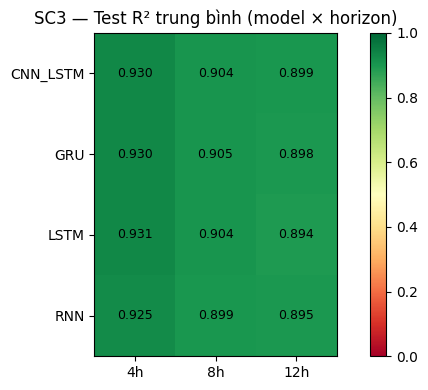

In [41]:
df = pd.read_csv(OUTPUT_DIR / "SC3_results.csv")

# So sánh model × horizon
pivot = df.groupby(["model","horizon_h"])["test_R2"].mean().unstack()
fig, ax = plt.subplots(figsize=(7,4))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([f"{c}h" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_title("SC3 — Test R² trung bình (model × horizon)")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(PLOT_DIR / "SC3_R2_heatmap.png", dpi=120)
plt.show()


## So sánh tổng hợp: SC1 (CauNoi) vs SC3 (All→BenLuc)

In [42]:
# Load cả 3 kịch bản nếu đã chạy
dfs = []
for sc in [1, 2, 3]:
    p = OUTPUT_DIR / f"SC{sc}_results.csv"
    if p.exists():
        d = pd.read_csv(p); dfs.append(d)

if dfs:
    all_results = pd.concat(dfs, ignore_index=True)
    all_results.to_csv(OUTPUT_DIR  / "all_scenarios_results.csv",  index=False)
    all_results.to_excel(OUTPUT_DIR / "all_scenarios_results.xlsx", index=False)
    print(f"Tổng hợp {len(all_results)} thí nghiệm → outputs/all_scenarios_results.*")
    
    summary = all_results.groupby(["scenario","model"])[["test_RMSE","test_MAE","test_R2"]] \
                         .mean().round(4)
    print("\nTrung bình theo kịch bản & model:")
    print(summary.to_string())


Tổng hợp 36 thí nghiệm → outputs/all_scenarios_results.*

Trung bình theo kịch bản & model:
                   test_RMSE  test_MAE  test_R2
scenario model                                 
SC2      CNN_LSTM     0.2190    0.1643   0.9112
         GRU          0.2190    0.1647   0.9112
         LSTM         0.2210    0.1683   0.9096
         RNN          0.2244    0.1728   0.9064
